# 1000 drug test run

This file runs a 1000 drug set (+ statins), along with multiple GIN runs at 6H in HT29 cells

Once the run is concluded, the best runs will be selected to pass to a consensus ranking for halo/paro/nita 

# Packages

In [2]:
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import pyarrow.parquet as pq
import random
import seaborn as sns
from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from tqdm import tqdm as tqdm
import warnings

# GIN
from sklearn.metrics.pairwise import cosine_similarity
import torch
from torch.nn import Sequential, Identity, Module, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.utils import from_networkx

# uMAP
import umap.umap_ as umap

# MISC
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Data, DataLoader, Batch
from tqdm import tqdm
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import hdbscan
from adjustText import adjust_text
from itertools import combinations

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\roman\AppData\Lo

# Directories

In [ ]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'

OUTPUT = 'D:/DDesktop/_work/data/canada/output/'

CDV = OUTPUT + 'cd_vectors/'

# Functions

In [ ]:
# GENERAL

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# GIN

def preprocess_graphs(list_pyg):
    '''
    Applies only common attributes to PyG graph objects (some graphs have extra 'dose' attribute that required removal)
    '''
    keys_to_keep = ['x', 'edge_index', 'num_nodes', 'name', 'timepoint']
    for g in list_pyg:
        # Remove unnecessary attributes
        for key in list(g.keys()):  # <-- call keys() as a method
            if key not in keys_to_keep:
                del g[key]

        # Make x 2D
        if g.x.dim() == 1:
            g.x = g.x.view(-1, 1)
    return list_pyg

class GINEncoder(torch.nn.Module):
    '''
    GIN encoder with message passing, a convolutional layer and a global pooling layer to generate a graph embedding
    '''
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            mlp = Sequential(Linear(in_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
            conv = GINConv(mlp)
            self.convs.append(conv)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
        graph_emb = global_add_pool(x, batch)  # graph-level embedding
        return graph_emb
    
def info_nce_loss(z1, z2, temperature=0.5):
    '''
    Information Noise-Contrastive Estimation as a loss function
    '''
    # Normalize embeddings
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    batch_size = z1.size(0)
    
    # Cosine similarity matrix
    representations = torch.cat([z1, z2], dim=0)  # [2*B, D]
    sim_matrix = torch.matmul(representations, representations.T)  # [2B,2B]
    
    # Scale by temperature
    sim_matrix = sim_matrix / temperature
    
    # Labels: each sample i in z1 matches i+B in z2, and vice versa
    labels = torch.arange(batch_size, device=z1.device)
    
    # Mask out self-similarities
    mask = torch.eye(2*batch_size, device=z1.device).bool()
    sim_matrix.masked_fill_(mask, -9e15)  # very large negative number instead of -inf
    
    # Positive logits
    positives = torch.cat([torch.arange(batch_size, batch_size*2), torch.arange(0, batch_size)]).to(z1.device)
    
    # Cross-entropy
    loss = F.cross_entropy(sim_matrix, positives)
    return loss

def augment_graph_batch(batch_graphs, noise_scale=0.1):
    '''
    Graph batch augmentation
    '''
    x_aug = batch_graphs.x + noise_scale * torch.randn_like(batch_graphs.x)
    batch_aug = Batch(batch_graphs.to_data_list())
    batch_aug.x = x_aug.to(batch_graphs.x.device)
    batch_aug.edge_index = batch_graphs.edge_index
    batch_aug.batch = batch_graphs.batch
    return batch_aug

def train_contrastive_gin(list_pyg, embed_dim=64, epochs=30, batch_size=4, lr=1e-3, device=None):
    '''
    Implementaion of GIN w/ contrastive learning loss function
    '''
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    # list_pyg = strip_graph_attributes(list_pyg)
    loader = DataLoader(list_pyg, batch_size=batch_size, shuffle=True)
    encoder = GINEncoder(input_dim=1, hidden_dim=embed_dim).to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

    #for epoch in tqdm(range(epochs), desc = f'Training contrastive GIN', total = epochs):
    for epoch in range(epochs):
        encoder.train()
        total_loss = 0
        #for batch_graphs in tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}'):
        for batch_graphs in loader:
            batch_graphs = batch_graphs.to(device)
            batch_aug = augment_graph_batch(batch_graphs)

            z1 = encoder(batch_graphs.x, batch_graphs.edge_index, batch_graphs.batch)
            z2 = encoder(batch_aug.x, batch_aug.edge_index, batch_aug.batch)

            loss = info_nce_loss(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        
        # Report loss per epoch
        #print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

    return encoder

def get_graph_embeddings(encoder, list_pyg, device=None):
    '''
    Generates graph embeddings using trained contrastive GIN
    '''
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    encoder.eval()
    embeddings = []
    graph_info = []
    with torch.no_grad():
        #for g in tqdm(list_pyg, desc="Generating embeddings"):
        for g in list_pyg:
            g = g.to(device)
            batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
            z = encoder(g.x, g.edge_index, batch)
            embeddings.append(z.cpu())
            graph_info.append({'name': g.name, 'timepoint': g.timepoint})
    embeddings = torch.cat(embeddings, dim=0).numpy()
    return embeddings, graph_info

def upper_tri(mat):
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]

def jaccard_similarity(set1, set2):
    '''
    Calculates jaccard similarity between sets of top n closest graphs to a reference graph
    '''
    return len(set1 & set2) / len(set1 | set2)

# Run

## PyG Graph List

Here:
- `graph_cds` is a pre-generated networkX graph object made up of 901 landmark genes (nodes) and their protein product interations
    - This forms the foundational structure onto which node signals are overlayed

- `df_cd` is a DataFrame containing the characteristic direction (CD) values for the same 901 genes (rows) for 3 treatments (columns) at the 6H timepoint
    - These values were derived from VST + quantile normalised gene counts

- `pf` is a Parquet file containing ~119k 901-gene vectors extracted from the L1000CDS2 online database
    - These can be directly overlayed onto `graph_cds` and form the set of comparison data to our 3 treatments
    - They are stored in Parquet format to allow for extraction of individual column data from a list of columns ('documents'), without having to load in the whole dataframe

In [5]:
# Load graph
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Load quantile CD vector data
df_cd = pd.read_csv(CDV + 'cd_quantile_landmark.csv')
# Set index
df_cd.set_index('gene_symbol', inplace = True)

# Load parquet file
pf = pq.ParquetFile(INPUT + 'df_attr.parquet')
# Load document list
list_documents = pf.schema.names
# Report
print(f'{len(list_documents):,} signatures in CDS data')

119,156 signatures in CDS data


In [6]:
# Define filters
CELL_LINES = ['HT29']
TIMEPOINTS = ['6H']

# Filter list_documents
list_signatures = [entry for entry in list_documents if
                   any(cell_line in entry for cell_line in CELL_LINES) and
                   any(timepoint in entry for timepoint in TIMEPOINTS)]
# Report
print(f'{len(list_signatures):,} signatures found for {CELL_LINES} cell lines and {TIMEPOINTS} timepoints')

# Get statins
list_statins = [entry for entry in list_documents if 
                'statin' in entry and 
                'poscon' not in entry and
                any(cell_line in entry for cell_line in CELL_LINES) and 
                any(timepoint in entry for timepoint in TIMEPOINTS)]
# Report
print(f'{len(list_statins):,} signatures found for statins in {CELL_LINES} cell line and {TIMEPOINTS} timepoints')

6,079 signatures found for ['HT29'] cell lines and ['6H'] timepoints
16 signatures found for statins in ['HT29'] cell line and ['6H'] timepoints


In [7]:
# Define number of random signatures
NUM_ENTRIES = 1000
# Sample signatures
list_random = random.sample(list_signatures, NUM_ENTRIES)
# Append statins
list_random = list_random + list_statins

`At this point, we have extracted the 901-gene vectors for the 3 known treatments, and 5 random drugs from the database (NUM_ENTRIES). To this, a list of 16 statin-specific gene vectors were added for direct comparison.`

`The next section overlays the gene vectors onto the graph_cds structure, for 3 treatments and the 5 random drugs + 16 statins`

In [8]:
# Define timepoint columns
list_columns = [column for column in df_cd.columns if '6h' in column]

# Initialise graph list
list_pyg = []

# Iterate through df_cd timepoint columns
for column in tqdm(list_columns, desc = 'Converting experimental data to PyG object(s)', total = len(list_columns)):

    # Get treatment name
    treatment_name = column.split('_')[2]
    # Get timepoint
    timepoint = column.split('_')[0].upper()

    # Extract column data as dictionary
    dict_column = df_cd[column].to_dict()
    
    # Copy graph_cds
    graph_column = graph_cds.copy()
    # Set node attributes
    nx.set_node_attributes(graph_column, dict_column, name = 'x')
    
    # Convert to PyG object
    pyg = from_networkx(graph_column)
    # Format 'x' attribute
    pyg.x = pyg.x.float()
    # Add treatment name
    pyg.name = f'{treatment_name}'
    # Add perturbagen timepoint
    pyg.timepoint = f'{timepoint}'
    # Append to graph list
    list_pyg.append(pyg)

# Iterate through list_random
for entry in tqdm(list_random, desc = 'Converting CDS data to PyG object(s)', total = len(list_random)):

    # Get signature ID
    signature_id = entry.split(':')[0]
    # Get cell line
    cell_line = signature_id.split('_')[1]
    # Get timepoint
    timepoint = signature_id.split('_')[2]
    # Get dose
    dose = entry.split(':')[2]

    # Get perturbagen name
    perturbagen_name = entry.split(':')[3]
    if '-666' in perturbagen_name:
        perturbagen_name = entry.split(':')[1]

    # Load signature from parquet file as dictionary
    dict_signature = pd.read_parquet(INPUT + 'df_attr.parquet', columns = [entry]).to_dict()
    dict_signature = dict_signature[entry]

    # Copy graph_cds
    graph_signature = graph_cds.copy()
    # Set node attributes
    nx.set_node_attributes(graph_signature, dict_signature, name = 'x')

    # Convert to PyG object
    pyg = from_networkx(graph_signature)
    # Format 'x' attribute
    pyg.x = pyg.x.float()
    # Add perturbagen anme
    pyg.name = f'{perturbagen_name}'
    # Add timepoint
    pyg.timepoint = f'{timepoint}'
    # Add dose
    pyg.dose = f'{dose}'
    # Add cell line
    pyg.cell = f'{cell_line}'
    # Append to graph list
    list_pyg.append(pyg)

Converting CDS data to PyG object(s): 100%|██████████| 1016/1016 [2:10:58<00:00,  7.73s/it] 


## GIN

`Next, the GIN is run multiple times (num_runs) to generate multiple sets of graph embeddings, which are then centered and normalised, and cosine similarity between all graphs within set of graph embeddings calculated (sim_matrices)`

In [9]:
warnings.filterwarnings('ignore')

# Save list_pyg
pickle_save(OUTPUT + 'list_pyg.pkl', list_pyg)
print('list_pyg saved')

# Define multi-run parameters
num_runs = 25
sim_matrices = []
graph_info_list = []

# Preprocess graph list
list_pyg = preprocess_graphs(list_pyg)

for seed in tqdm(range(num_runs), desc = 'Multiple GIN runs', total = num_runs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    encoder = train_contrastive_gin(list_pyg, embed_dim=64, epochs=150, batch_size=32)
    embeddings, graph_info = get_graph_embeddings(encoder, list_pyg)

    # Center and normalize
    emb_centered = embeddings - embeddings.mean(axis=0, keepdims=True)
    emb_norm = emb_centered / np.linalg.norm(emb_centered, axis=1, keepdims=True)

    sim_matrices.append(cosine_similarity(emb_norm))
    graph_info_list = graph_info  # same across runs

list_pyg saved


Multiple GIN runs: 100%|██████████| 25/25 [45:41<00:00, 109.66s/it]


## Results Consistency

`In order to look at consistency of results, various metrics (correlation, spearman rank correlation, jaccard similarity) were calcultated using cosine similarities of graphs to a reference graph ('halo'), and the top k (k=10) most similar graphs returned for that reference graph. A combined score was calculated to take into account all metrics, and see which runs are most 'trustworthy' from which to extract the most consistent similar graphs (consensus embedding)`

In [10]:
# Define reference treatment
REF_TREATMENT = 'halo'
# Reference graph index
ref_idx = next(i for i, g in enumerate(graph_info_list) if REF_TREATMENT in g['name'])

# Compute pairwise correlations
corr_matrix = np.zeros((num_runs, num_runs))
spearman_matrix = np.zeros((num_runs, num_runs))

for i in range(num_runs):
    for j in range(i+1, num_runs):
        # Pearson correlation of upper triangles
        corr = np.corrcoef(upper_tri(sim_matrices[i]), upper_tri(sim_matrices[j]))[0, 1]
        corr_matrix[i, j] = corr_matrix[j, i] = corr

        # Spearman rank correlation for reference graph similarities
        rho, _ = spearmanr(sim_matrices[i][ref_idx], sim_matrices[j][ref_idx])
        spearman_matrix[i, j] = spearman_matrix[j, i] = rho

# Compute consistency per run
mean_corr = corr_matrix.mean(axis=1)
mean_spearman = spearman_matrix.mean(axis=1)

# Compute top-k overlapp Jaccard metric between runs
k = 10
jaccard_matrix = np.zeros((num_runs, num_runs))

for i, j in combinations(range(num_runs), 2):
    top_i = set(np.argsort(-sim_matrices[i][ref_idx])[:k])
    top_j = set(np.argsort(-sim_matrices[j][ref_idx])[:k])
    jacc = jaccard_similarity(top_i, top_j)
    jaccard_matrix[i, j] = jaccard_matrix[j, i] = jacc

mean_jaccard = jaccard_matrix.mean(axis=1)

consistency_df = pd.DataFrame({
    'run': range(num_runs),
    'mean_corr': mean_corr,
    'mean_spearman': mean_spearman,
    'mean_jaccard' : mean_jaccard,
    'combined_score': 0.5 * (mean_corr + mean_spearman) + 0.5 * mean_jaccard
}).sort_values('combined_score', ascending=False)

consistency_df.head(25)

,run,mean_corr,mean_spearman,mean_jaccard,combined_score
24,24,0.931385,0.798728,0.488803,1.109458
21,21,0.933601,0.791765,0.472525,1.098946
7,7,0.935616,0.800116,0.461796,1.098764
1,1,0.934817,0.803459,0.456358,1.097317
18,18,0.932514,0.770758,0.488803,1.096037
23,23,0.915327,0.799340,0.461796,1.088231
5,5,0.935425,0.768816,0.456263,1.080252
2,2,0.935763,0.790835,0.418754,1.072676
0,0,0.924522,0.784051,0.426878,1.067726
8,8,0.937037,0.798342,0.398485,1.066932


## Consensus embedding

`From these results, a subset of 5 top runs were taken as representative of 'real' results. The graph embedding vectors generated from these 5 runs were averaged to provide a consensus embedding, from which the top k (k=10) graphs most similar to a reference graph ('halo') were extracted to test for some biological relevance`

In [46]:
# Define reference treatment
REF_TREATMENT = 'nita'
# Reference graph index
ref_idx = next(i for i, g in enumerate(graph_info_list) if REF_TREATMENT in g['name'])

# Define list of runs to use from consistency_df
#list_runs_idx = [24, 21, 7, 1, 18]
list_runs_idx = consistency_df['run'].values[0:5]
embeddings_list = [sim_matrices[i] for i in list_runs_idx]

# Stack embeddings: shape = (num_runs, num_graphs, embed_dim)
stacked_embs = np.stack([embeddings_per_run for embeddings_per_run in embeddings_list], axis=0)
consensus_emb = np.mean(stacked_embs, axis=0)  # average across runs

# Center and normalize
consensus_emb -= consensus_emb.mean(axis=0, keepdims=True)
consensus_emb /= np.linalg.norm(consensus_emb, axis=1, keepdims=True)

# Calculate cosine similarity
sim_matrix = cosine_similarity(consensus_emb)

# Get all ranked graphs
all_idx = np.argsort(sim_matrix[ref_idx])[::-1][1:]
# Get top k closest graphs to REF_TREATMENT
top_idx = np.argsort(sim_matrix[ref_idx])[::-1][1:11]  # exclude self

# Build DataFrame
df_consensus = pd.DataFrame([
    (graph_info_list[i]['name'], graph_info_list[i]['timepoint'], sim_matrix[ref_idx, i])
    for i in all_idx
], columns=['name','timepoint','cosim'])

df_consensus.head(10)

,name,timepoint,cosim
0,paro,6H,0.984927
1,HY-10459,6H,0.975668
2,BRD-K04853698,6H,0.971718
3,BRD-K04548931,6H,0.970944
4,BRD-A30437061,6H,0.965554
5,BRD-K17953061,6H,0.964171
6,BRD-K14618467,6H,0.962685
7,BRD-K35133769,6H,0.962125
8,TENIPOSIDE,6H,0.959829
9,Chlorphensin carbamate,6H,0.959214


## uMAP

`The consensus set of graph embedding vectors were passed to the uMAP agorithm for dimensonality reduction and visualisation`

In [45]:
df_consensus['name'][6]

'2-[(chloroacetyl)(4-methoxyphenyl)amino]-N-(2-phenylethyl)-2-thien-2-ylacetamide'

In [25]:
df_consensus[df_consensus['name'].str.contains('statin')]

,name,timepoint,cosim
35,Dephostatin,6H,0.791553
118,Pepstatin A,6H,0.762964
120,itavastatin ca,6H,0.762041
181,bestatin,6H,0.742240
413,blebbistatin,6H,0.575356
522,cerivastatin na,6H,-0.535773
601,trichostatin A,6H,-0.594288
619,trichostatin A,6H,-0.603271
652,cilastatin na,6H,-0.617709
653,cilastatin na,6H,-0.617709


In [32]:
# Load
df = pd.read_csv(INPUT + 'cds2_res.tsv', sep = '\t')
# Get names
list_names = pd.unique(df['Perturbation'])
# Get location
df_consensus[df_consensus['name'].isin(list_names)]

,name,timepoint,cosim
423,BRD-K01614657,6H,0.565037
484,PERHEXILINE MALEATE,6H,-0.081457
689,EMETINE,6H,-0.634600


In [18]:
# uMAP
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(consensus_emb)
graph_ids = [g.name for g in list_pyg]
graph_timepoints = [g.timepoint for g in list_pyg]

# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_name'] = graph_ids
df_plot['timepoint'] = graph_timepoints

# Show data
df_plot.head()

,x,y,perturbagen_name,timepoint
0,0.905683,-9.818682,halo,6H
1,11.999017,-9.493021,nita,6H
2,12.010332,-9.507481,paro,6H
3,10.972755,8.433558,BRD-K50325075,6H
4,13.824524,9.364500,ALFLUZOSIN,6H


`The results of the uMAP reduction were plotted, highlighting known 3 treatments, all statins, and atorvastatin specifically`

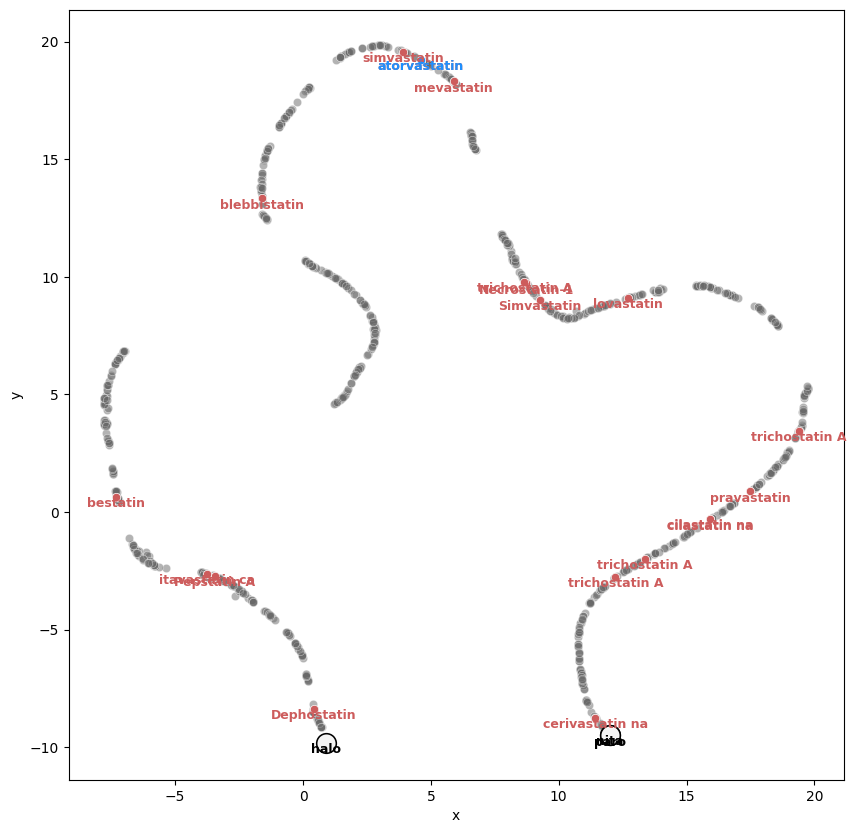

In [19]:
# Plot
list_known_ids = ['halo', 'nita', 'paro']

# Generate plot subsets
subset = df_plot[df_plot['perturbagen_name'].isin(list_known_ids)]
statins = df_plot[df_plot['perturbagen_name'].str.contains('statin')]
ator = df_plot[df_plot['perturbagen_name'].str.contains('atorvastatin')]

# Plot
plt.figure(figsize = (10,10))
sns.scatterplot(df_plot, x = 'x', y = 'y', c = 'dimgrey', alpha = 0.5)
sns.scatterplot(statins, x = 'x', y = 'y', c = 'indianred')
sns.scatterplot(ator, x = 'x', y = 'y', c = 'dodgerblue')
sns.scatterplot(subset, x = 'x', y = 'y', s = 200, c = 'whitesmoke', edgecolor = 'black', legend = None, label = 'perturbagen_name')

# Add text labels for each highlighted point
for _, row in subset.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='black'
    )

# Add text labels for each highlighted point
for _, row in statins.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='indianred'
    )

# Add text labels for each highlighted point
for _, row in ator.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='dodgerblue'
    )

## Clustering

`Clustering was run on the consensus embeddings using HDBScan, with default parameters`

In [38]:
# Initialise clustering
#clusterer = hdbscan.HDBSCAN()
clusterer = hdbscan.HDBSCAN(min_cluster_size = 10)
# Get cluster labels
labels = clusterer.fit_predict(consensus_emb)

# Initialise dataframe
df_cluster = df_plot.copy()
df_cluster['cluster'] = labels

# Report number of clusters identified
num_clusters = len(pd.unique(df_cluster['cluster']))
print(f'{num_clusters} clusters identified')

# Show data
df_cluster.head()

8 clusters identified


,x,y,perturbagen_name,timepoint,cluster
0,0.905683,-9.818682,halo,6H,-1
1,11.999017,-9.493021,nita,6H,-1
2,12.010332,-9.507481,paro,6H,-1
3,10.972755,8.433558,BRD-K50325075,6H,5
4,13.824524,9.364500,ALFLUZOSIN,6H,6


`For each cluster, the centroid was calculated, and the closest drug to that centroid was highlighted as representative of that cluster`

In [39]:
# Initialise list
representatives = []

# Iterate through identified clusteres
for label, cluster in df_cluster.groupby('cluster'):
    # Check for labels > -1 (points designated as 'noise')
    if label > -1:
        # Get cluster centroid
        centroid = cluster[['x', 'y']].mean().values
        # Calculate distances of each drug in cluster to centroid
        distances = np.linalg.norm(cluster[['x', 'y']].values - centroid, axis=1)
        # Get closest drug
        closest_drug = cluster.index[np.argmin(distances)]
        # Append to list
        representatives.append(df_cluster.loc[closest_drug])
    
# Convert to dataframe
df_representatives = pd.DataFrame(representatives)
# Show data
df_representatives.head()

,x,y,perturbagen_name,timepoint,cluster
209,1.229201,4.593459,Raf1 Kinase Inhibitor I,6H,0
813,0.220799,18.074890,7108921,6H,1
956,5.788677,18.409922,BRD-A12409803,6H,2
585,6.585957,15.970823,Parthenolide,6H,3
681,8.507972,10.101235,BRD-K77677632,6H,4


`Cluster membership and representative graphs were overlayed onto uMAP coordinates for visualisation`

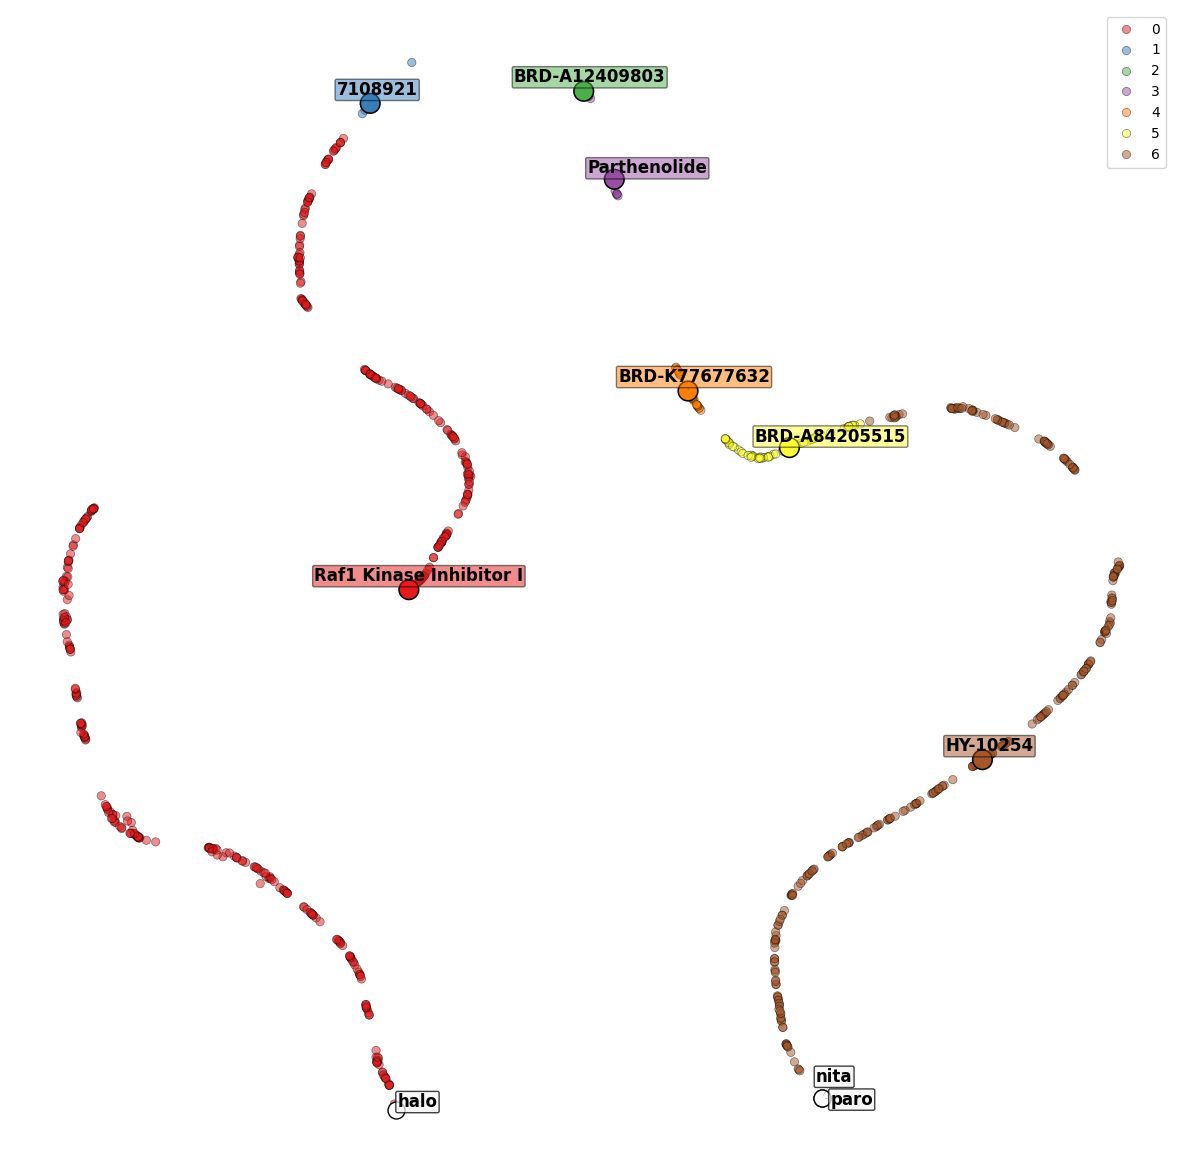

In [40]:
# Plot
plt.figure(figsize = (15,15))
plt.axis('off')

# Plot clusters
sns.scatterplot(df_cluster[df_cluster['cluster'] != -1], 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                alpha = 0.5, edgecolors = 'black')
# Plot representative points
sns.scatterplot(df_representatives, 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                edgecolors = 'black', s = 200, legend = False)
# Plot known anti-malarials
sns.scatterplot(df_cluster[df_cluster['perturbagen_name'].isin(list_known_ids)], 
                x = 'x', y = 'y', 
                c = 'white', s = 150, alpha = 1, edgecolors = 'black')

# Set label styling
malarial_style = {'fontsize': 12,
                  'alpha' : 1,
                  'weight' : 'bold',
                  'color': 'black',
                  'bbox': {'facecolor': 'whitesmoke',
                           'alpha': 0.75,
                           'edgecolor': 'black',
                           'boxstyle': 'round,pad=0.1'}}

# Initialise text label list
texts = []

# Iterate through anti-malarial IDs
for id in list_known_ids:
    # Slice dataframe
    df_slice = df_cluster[df_cluster['perturbagen_name'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]
    # Append with styling
    texts.append(plt.text(x, y, label, **malarial_style));

# Adjust labels
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
            expand = (1,1));

# Initialise representative text label list
rep_texts = []

# Get first n colours from Set1 palette
n = 10
palette_colors = list(sns.color_palette('Set1', n_colors=n))

# Iterate through representative drug IDs and palette colours
for id, colour in zip(pd.unique(df_representatives['perturbagen_name']), palette_colors):
    # Slice dataframe
    df_slice = df_representatives[df_representatives['perturbagen_name'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]

    # Set label styling
    rep_style = {'fontsize': 12,
                 'alpha' : 1,
                 'weight' : 'bold',
                 'color': 'black',
                 'ha': 'center',             
                 'va': 'bottom',             
                 'bbox': {'facecolor': colour,
                          'alpha': 0.5,
                          'edgecolor': 'black',
                          'boxstyle': 'round,pad=0.1'}}

    # Append with styling
    rep_texts.append(plt.text(x, y, label, **rep_style))

# Adjust text labels
adjust_text(rep_texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25));

# Show plot
plt.show()